In [1]:
import pandas as pd
import matplotlib as plt
from sklearn import linear_model

In [52]:
df = pd.read_csv("dataset/capita_income.csv")
df.head(5)

,year,Income
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583


In [53]:
reg = linear_model.LinearRegression()
reg.fit(df[['year']].values,df.Income)

LinearRegression()

c:\Users\Shree\anaconda3\Lib\site-packages\sklearn\base.py:457: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


Text(0, 0.5, 'Income')

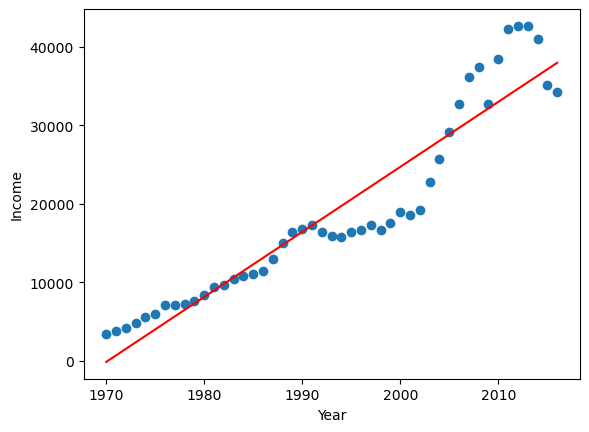

In [55]:
import matplotlib.pyplot as plt
plt.scatter(df.year,df.Income)
plt.plot(df.year,reg.predict(df[['year']]),color="red")
plt.xlabel("Year")
plt.ylabel("Income")



In [51]:
#  predict the income --> y = mx+c
m = reg.coef_
c = reg.intercept_
reg.predict([[2000]])

# plotting the linear line that we generated for each value



array([24719.39258996])

In [56]:
# Multi variate regression analysis
df_1 = pd.read_csv("dataset/hiring.csv")
df_1.head(5)

,experience,test_score,interview_score,salary
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000


In [58]:
import math
m_test = math.floor(df_1.test_score.median())
df_1.test_score = df_1.test_score.fillna(m_test)
exp_map = {
    'zero': 0,
    'one': 1,
    'two': 2,
    'three': 3,
    'four': 4,
    'five': 5,
    'six': 6,
    'seven': 7,
    'eight': 8,
    'nine': 9,
    'ten': 10
}

df_1['experience'] = df_1['experience'].map(exp_map)
df_1['experience'] = df_1['experience'].fillna(0)
# df['experience'] = df['experience'].fillna("zero")
df_1.head(5)



,experience,test_score,interview_score,salary
0,0.0,8.0,9,50000
1,0.0,8.0,6,45000
2,5.0,6.0,7,60000
3,2.0,10.0,10,65000
4,7.0,9.0,6,70000


In [59]:
reg_multi = linear_model.LinearRegression()
reg_multi.fit(df_1[['experience','test_score','interview_score']],df_1.salary)

LinearRegression()

In [60]:
reg_multi.predict(pd.DataFrame([[2,10,10]]))

c:\Users\Shree\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([63433.12313309])

In [ ]:
import pickle
# can also use joblib -->
# if modle contain large numpy array then prefer joblib

In [62]:
with open('model_pickle','wb') as f:
    pickle.dump(reg,f)

In [65]:
#  for access or read the model form above stored file
with open('model_pickle','rb') as f:
    mp = pickle.load(f)

In [ ]:
mp.predict([[2000]])
# can transfer this model and anyone can use it

array([24719.39258996])

In [70]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [71]:
import joblib

joblib.dump(reg_multi,'multi_model.pkl')

['multi_model.pkl']

In [73]:
mm = joblib.load('multi_model.pkl')
mm.predict(pd.DataFrame([[2,10,10]]))

c:\Users\Shree\anaconda3\Lib\site-packages\sklearn\base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([63433.12313309])